# Bounding the trend book

The headline is a market-timing beta, 0.80 Sharpe for the market book and 0.85 per coin. It fails the pooled bar out of sample and it is one honest number, not a proven strategy. Before it goes in a write-up, bound how uncertain that number is and see how the book behaves in the crashes it is meant to earn through.

Block bootstrap the weekly net returns for a confidence interval on the Sharpe. Then read the cumulative return through the known breaks, and the Sharpe year by year.

## Setup

Rebuild the two 4-week books, per coin and market, sized for equal risk on $10M coins.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import panel

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2})
BLUE, ORANGE = '#2a78d6', '#eb6834'

p = panel.load()
W, R, LIQ, VOL, F = p.weekly, p.simple.fillna(0.0), p.liquidity, p.vol, p.funding
COST = pd.DataFrame(np.where(LIQ >= 1e7, 7.5e-4, 15e-4), index=LIQ.index, columns=LIQ.columns)

def run(w, cost_mult=1.0):
    w = w.fillna(0.0)
    turn = (w - w.shift(1).fillna(0.0)).abs()
    net = (w * R).sum(axis=1) - (w * F).sum(axis=1) - (turn * COST * cost_mult).sum(axis=1)
    return net.loc[(w.abs().sum(axis=1) > 0).idxmax():]

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(52) if len(x) > 2 and x.std() > 0 else np.nan

def sized(sig, floor=1e7):
    elig = (LIQ >= floor) & VOL.notna() & (VOL > 0) & sig.notna()
    raw = (sig / VOL).where(elig)
    return raw.div(raw.abs().sum(axis=1), axis=0)

liquid = LIQ >= 1e7
market_ret = W.where(liquid).mean(axis=1)
basket = sized(pd.DataFrame(1.0, index=W.index, columns=W.columns).where(W.shift(1).notna()))
per_coin = run(sized(np.sign(W.rolling(4, min_periods=4).sum()).shift(1)))
market = run(basket.mul(np.sign(market_ret.rolling(4, min_periods=4).sum()).shift(1), axis=0))
print(f'market {sharpe(market):.2f}   per_coin {sharpe(per_coin):.2f}   weeks {len(per_coin)}')

market 0.80   per_coin 0.85   weeks 336


## How uncertain is the Sharpe

Resample the weekly net returns in 8-week blocks, 5000 draws, and read the 5th, 50th and 95th percentile of the bootstrapped Sharpe, and the fraction of draws above zero. Blocks keep the short-run autocorrelation intact.

In [2]:
def block_boot(x, block=8, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    v = x.values; L = len(v); nb = int(np.ceil(L / block))
    starts = rng.integers(0, L - block + 1, size=(n, nb))
    out = np.array([np.concatenate([v[a:a + block] for a in s])[:L] for s in starts])
    sr = out.mean(1) / out.std(1) * np.sqrt(52)
    return np.percentile(sr, [5, 50, 95]), (sr > 0).mean()

rows = []
for name, x in [('market', market), ('per_coin', per_coin)]:
    (p5, p50, p95), pos = block_boot(x)
    rows.append({'book': name, 'Sharpe': sharpe(x), 'boot 5%': p5, 'boot 50%': p50, 'boot 95%': p95, 'frac > 0': pos})
print(pd.DataFrame(rows).set_index('book').round(2))

          Sharpe  boot 5%  boot 50%  boot 95%  frac > 0
book                                                   
market      0.80     0.29      0.86      1.42      0.99
per_coin    0.85     0.36      0.92      1.47      1.00


The edge is real but imprecise. Both books put the 5th percentile of the bootstrapped Sharpe above zero, 0.29 for the market and 0.36 per coin, and are positive in essentially every draw. The interval is wide though, 0.29 to 1.42, so the point estimate carries a large error. A real premium, loosely measured.

## Through the crashes

Cumulative net return of each book across the sample's known breaks. Trend is meant to earn in these.

In [3]:
windows = {'May 2021 flush': ('2021-05-01', '2021-05-31'), 'LUNA 2022': ('2022-05-01', '2022-06-30'),
           'FTX 2022': ('2022-11-01', '2022-11-30'), 'Mar 2023 depeg': ('2023-03-01', '2023-03-31'),
           'Aug 2024 unwind': ('2024-08-01', '2024-08-18')}
rows = []
for wn, (a, b) in windows.items():
    rows.append({'window': wn, 'weeks': len(market.loc[a:b]),
                 'market %': market.loc[a:b].sum() * 100, 'per_coin %': per_coin.loc[a:b].sum() * 100})
print(pd.DataFrame(rows).set_index('window').round(1))

                 weeks  market %  per_coin %
window                                      
May 2021 flush       5      63.8       -16.0
LUNA 2022            9      69.3        63.3
FTX 2022             4     -27.2        -1.3
Mar 2023 depeg       4     -13.5        -6.6
Aug 2024 unwind      3      18.2         5.1


Trend's crash behaviour is the textbook shape. It earns large in sustained crashes, the market book up 64% through the May 2021 flush and 69% through the LUNA collapse, per coin up 63% through LUNA. It loses in sharp reversals, the market book down 27% through the FTX week and 14% through the March 2023 depeg, where price snapped back before the signal could turn. Per coin was flatter through both, near minus 1 and minus 7.

The one split is May 2021, where the market book caught the flush but per coin lost 16%, the coins scattered while the index fell. Crisis alpha in one-way moves, whipsaw losses when a crash reverses.

## Year by year

      market  per_coin
year                  
2020   -0.63      1.06
2021    1.73      1.69
2022    0.76      0.79
2023    1.06      0.82
2024    0.44      0.25
2025    1.27      1.15
2026   -0.53     -0.64


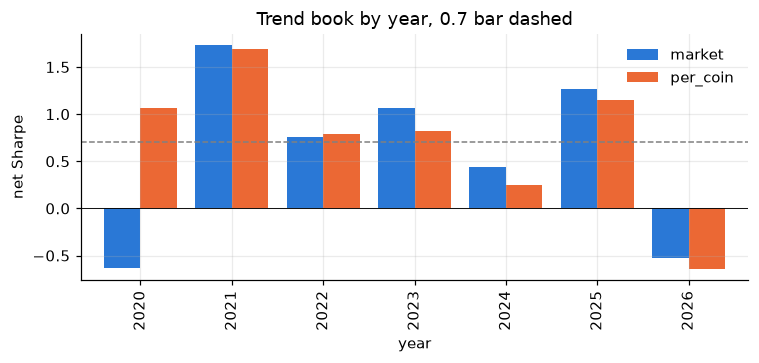

In [4]:
yr = pd.DataFrame({'market': market.groupby(market.index.year).apply(sharpe),
                   'per_coin': per_coin.groupby(per_coin.index.year).apply(sharpe)}).round(2)
yr.index.name = 'year'
print(yr)
fig, ax = plt.subplots(figsize=(7, 3.4))
yr.plot.bar(ax=ax, color=[BLUE, ORANGE], width=0.8)
ax.axhline(0, color='k', lw=0.6); ax.axhline(0.7, color='grey', ls='--', lw=1)
ax.set_ylabel('net Sharpe'); ax.set_title('Trend book by year, 0.7 bar dashed')
ax.legend(frameon=False); plt.tight_layout(); plt.show()

Only 2026 is negative in both books, and 2020 for the market alone. Every other year clears zero and most clear the 0.7 bar. The result does not lean on a single year.

## Verdict

The trend book is a real but loosely measured premium. The Sharpe is 0.80, with a bootstrap floor near 0.3 and a wide ceiling, positive in essentially every resample. Its crash profile is classic trend, large gains in sustained moves and whipsaw losses when a crash reverses, so it earns its keep as a diversifier in one-way markets and pays for it in choppy ones. Only 2026 loses across the board.

This bounds the headline for the write-up. It does not change the pooled-bar failure. The book is honest beta, loosely measured, not a passed strategy.